# Bridge Transfers and Quarantine in a Captive Turtle Farm

This notebook explains the model, reruns one example and presents the completed formal experiment and separate duration/policy follow-up. It uses the existing `turtlefarm` package and committed results. Running all cells does not change the experiment files or start a new batch.

The formal results show that transfer rate strongly changes outbreak size. With a budget of two tanks for 14 days, highest-betweenness quarantine does not consistently outperform random quarantine. The example below illustrates the rules; the repeated experiment supports the conclusions.

## 1. Research questions

**Primary:** How do cross-tank transfer rate and response delay affect the final outbreak size and the number of affected tanks in a modular captive-turtle housing system?

**Secondary:** Under the same intervention budget, does quarantining high-betweenness tanks reduce disease spread more effectively than quarantining randomly selected tanks?

This is a stylised explanatory model with synthetic agents and networks, not a prediction for a real turtle farm. See the [model specification](../data/methods/model.md). The report is submitted separately through LMS.

## 2. Setup

Use Python 3.12 and install `requirements.txt` from the repository root. Open this file in JupyterLab or VS Code, select that Python environment, then choose **Restart Kernel and Run All**. The README gives the commands.

The notebook reads the committed design and result tables, runs five example simulations in memory and recalculates the displayed statistical summaries. It does not need the large raw JSONL files. Saved outputs can also be read without running the notebook.

In [1]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Find the repository from either its root or the notebooks directory.
ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src/turtlefarm").is_dir()
     and (path / "data/config/formal-nested.json").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook inside the project repository.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from turtlefarm.analysis import condition_summary, paired_differences, paired_effect_table
from turtlefarm.model import run_baseline
from turtlefarm.network import generate_network
from turtlefarm.runner import ExperimentDesign, configuration_hash

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "figure.facecolor": "white",
})
STRATEGIES = ("none", "random", "betweenness")
LABELS = {"none": "No quarantine", "random": "Random", "betweenness": "Highest betweenness"}
COLORS = {"none": "#2a78d6", "random": "#eb6834", "betweenness": "#1baf7a"}
MARKERS = {"none": "o", "random": "s", "betweenness": "^"}
PRIMARY = ("final_attack_rate", "affected_tanks")

display(pd.DataFrame({
    "Package": ["Python", "NumPy", "pandas", "NetworkX"],
    "Version": [sys.version.split()[0], np.__version__, pd.__version__, nx.__version__],
}))

,Package,Version
0,Python,3.12.14
1,NumPy,2.5.2
2,pandas,3.0.5
3,NetworkX,3.6.1


## 3. Model rules

There are 200 turtle agents in 20 tanks, grouped into four regions. Each turtle has a current tank and a disease state: susceptible (`S`), infectious (`I`) or recovered (`R`). Each tank is open or quarantined. An edge permits a direct transfer between two tanks.

One simulation step represents one day. The code repeats this sequence until no infectious turtles remain or the time limit is reached:

1. Start or end quarantine.
2. Process movement attempts in random order. Each turtle attempts a transfer with probability $\mu$. The model checks quarantine and capacity before accepting a move.
3. Take a snapshot after movement. If a tank has $I_j$ infectious turtles, each susceptible turtle is infected with probability $1-(1-\beta)^{I_j}$.
4. Each turtle already infectious in that snapshot recovers with probability $\gamma$.
5. Apply infections and recoveries together, record the day and check whether the run has ended.

A newly infected turtle cannot transmit or recover until the next day. Recovery gives immunity for the rest of the run; recovered turtles can still move and occupy tank space. A run can end with both susceptible and recovered turtles.

### Assumptions and strategies

Mixing within a tank is complete. The network is fixed, disease state does not affect movement, and births and deaths are outside the model.

| Strategy | Tank selection | What changes during quarantine? |
|---|---|---|
| `none` | No tanks | Movement follows the network and capacity rules. |
| `random` | Two tanks chosen using a policy seed | Transfers into and out of those tanks are blocked. |
| `betweenness` | The two tanks with highest pre-outbreak betweenness | The same movement restriction applies. |

Within-tank transmission and recovery continue during quarantine. Both quarantine strategies use the same duration and planned budget. Betweenness measures shortest-path bridging, not simply the number of neighbours.

The implementation is in [model.py](../src/turtlefarm/model.py), [network.py](../src/turtlefarm/network.py) and [rng.py](../src/turtlefarm/rng.py).

In [2]:
design_path = ROOT / "data/config/formal-nested.json"
design = ExperimentDesign.from_json(design_path)
configs = design.configs()
intervention_config = next(cfg for cfg in configs if cfg.strategy == "betweenness")

parameter_rows = [
    ("Agents / tanks / regions", f"{intervention_config.n_agents} / {intervention_config.n_tanks} / {intervention_config.n_regions}", "Synthetic population and housing"),
    ("Initial occupancy / infections", f"{intervention_config.initial_per_tank} per tank / {intervention_config.initial_infected} infection", "One infected agent is selected randomly"),
    ("Tank capacity", intervention_config.capacity, "Maximum turtles in one tank"),
    ("beta", intervention_config.beta, "Daily transmission probability per infectious contact"),
    ("gamma", intervention_config.gamma, "Daily recovery probability"),
    ("p_in / p_out", f"{intervention_config.p_in} / {intervention_config.p_out}", "Within-region / between-region edge probabilities"),
    ("Transfer rates (mu)", ", ".join(map(str, design.transfer_rates)), "Daily transfer-attempt probability per turtle"),
    ("Response delays", ", ".join(map(str, design.response_delays)), "Days from infection introduction on day 0"),
    ("Quarantined tanks (k)", intervention_config.k, "Equal for both quarantine strategies"),
    ("Duration (D)", intervention_config.quarantine_duration, "Days; planned budget = k x D"),
    ("Maximum run length", intervention_config.max_days, "Days; an unfinished outbreak is censored"),
]
display(pd.DataFrame(parameter_rows, columns=["Parameter", "Value", "Meaning"]).set_index("Parameter"))

,Value,Meaning
Parameter,,
Agents / tanks / regions,200 / 20 / 4,Synthetic population and housing
Initial occupancy / infections,10 per tank / 1 infection,One infected agent is selected randomly
Tank capacity,12,Maximum turtles in one tank
beta,0.2,Daily transmission probability per infectious ...
gamma,0.1,Daily recovery probability
p_in / p_out,0.6 / 0.05,Within-region / between-region edge probabilities
Transfer rates (mu),"0.0, 0.01, 0.025, 0.1",Daily transfer-attempt probability per turtle
Response delays,"1, 12, 33",Days from infection introduction on day 0
Quarantined tanks (k),2,Equal for both quarantine strategies


## 4. Formal design and data checks

The formal design uses 20 networks and five distinct epidemic seeds per network: 100 paired blocks at each transfer rate. Epidemic seeds are nested within networks, not reused across networks. Each block contains one shared no-quarantine baseline plus, at each of three response delays, one targeted run and three random-policy runs.

That gives $4 \times 100 \times [1+3\times(1+3)] = 5{,}200$ runs. The baseline is not run again for each delay.

The checks below compare configuration hashes with the design, check seed allocation and account for every run. A missing, duplicated or unfinished run stops this notebook rather than being silently omitted.

In [3]:
summary_path = ROOT / "data/results/summary/formal-nested.csv"
analysis_dir = ROOT / "data/results/analysis/formal-nested"
summary = pd.read_csv(summary_path)
expected_hashes = {configuration_hash(cfg.to_dict()) for cfg in configs}
assert summary["configuration_hash"].is_unique, "Duplicate run configuration."
assert set(summary["configuration_hash"]) == expected_hashes, "Missing or unexpected configurations."
assert len(summary) == len(configs) == 5200
assert summary["status"].eq("completed").all(), "Inspect failed or censored runs before analysis."
assert summary[list(PRIMARY)].notna().all().all()
assert summary["final_attack_rate"].between(0, 1).all()
assert summary["affected_tanks"].between(1, intervention_config.n_tanks).all()

seed_pairs = summary[["network_seed", "epidemic_seed"]].drop_duplicates()
assert seed_pairs.groupby("epidemic_seed")["network_seed"].nunique().eq(1).all()
assert seed_pairs.groupby("network_seed").size().eq(5).all()
assert len(seed_pairs) == 100

display(summary.groupby(["strategy", "status"]).size().rename("Runs").to_frame())
print(f"Checked {len(summary):,} configurations across {len(seed_pairs)} network/epidemic pairs.")

source_paths = [design_path, summary_path, analysis_dir / "fig7-selection.json",
                analysis_dir / "condition-summary.csv", analysis_dir / "paired-effects.csv"]
display(pd.DataFrame([
    {"Source": str(path.relative_to(ROOT)),
     "SHA-256 (first 16 characters)": hashlib.sha256(path.read_bytes()).hexdigest()[:16]}
    for path in source_paths
]))

,,Runs
strategy,status,
betweenness,completed,1200
none,completed,400
random,completed,3600


Checked 5,200 configurations across 100 network/epidemic pairs.


,Source,SHA-256 (first 16 characters)
0,data/config/formal-nested.json,f1b1023fdae667c4
1,data/results/summary/formal-nested.csv,d5233a22c00bb65a
2,data/results/analysis/formal-nested/fig7-selec...,074cf1dd920ab932
3,data/results/analysis/formal-nested/condition-...,6e76f321720509cc
4,data/results/analysis/formal-nested/paired-eff...,4a5477ea2b9ddd3b


## 5. Run one paired example

This example uses the cross-region baseline in the [representative-run figure](../data/results/analysis/formal-nested/fig7-representative-runs.png). The recorded selection rule chooses a baseline close to its outbreak class median; it does not select a case based on which intervention looks best. The rule was adopted after the formal results and is recorded in the [decision log](../data/methods/decisions.md).

We use response delay 33 and run all five arms: no quarantine, highest-betweenness quarantine and the three random-policy seeds. Every arm uses the same network and epidemic seed. Event-keyed draws keep corresponding random events paired even after the trajectories diverge.

The block below is selected from the existing design. To explore another formal block, change its network seed, epidemic seed, transfer rate or response delay to a valid combination and rerun from this cell. The stored-result checks still apply. Exploration of settings outside the formal design belongs in a separate experiment.

In [4]:
selection = json.loads((analysis_dir / "fig7-selection.json").read_text())
representative = selection["cross_region"]
example_network = representative["network_seed"]
example_epidemic = representative["epidemic_seed"]
example_rate = representative["config"]["transfer_rate"]
example_delay = max(design.response_delays)

example_configs = [
    cfg for cfg in configs
    if cfg.network_seed == example_network
    and cfg.epidemic_seed == example_epidemic
    and cfg.transfer_rate == example_rate
    and (cfg.strategy == "none" or cfg.response_delay == example_delay)
]
assert len(example_configs) == 2 + len(design.policy_seeds), "Choose a valid formal block."
records = [run_baseline(cfg) for cfg in example_configs]
stored_by_hash = summary.set_index("configuration_hash")
example_rows = []
for cfg, record in zip(example_configs, records):
    assert record.status == "completed", record.error
    stored = stored_by_hash.loc[configuration_hash(cfg.to_dict())]
    for metric, value in record.metrics.items():
        if metric in stored.index:
            np.testing.assert_allclose(value, stored[metric], rtol=0, atol=1e-12)
    assert record.network["network_hash"] == stored["network_hash"]
    for field in ("attempted_transfers", "accepted_transfers", "blocked_transfers"):
        assert sum(getattr(day, field) for day in record.daily) == stored[field]
    example_rows.append({
        "Strategy": LABELS[cfg.strategy],
        "Policy seed": "-" if cfg.policy_seed is None else str(cfg.policy_seed),
        "Selected tanks": ", ".join(map(str, record.selected_tanks)) or "-",
        "Attack rate (%)": 100 * record.metrics["final_attack_rate"],
        "Affected tanks": record.metrics["affected_tanks"],
        "Peak infected": record.metrics["peak_infected"],
        "Extinction day": record.metrics["time_to_extinction"],
        "Budget (tank-days)": record.intervention_cost,
    })

print(f"Network {example_network}; epidemic seed {example_epidemic}; mu={example_rate}; delay={example_delay} days")
display(pd.DataFrame(example_rows).round(1))
print("All five runs match the stored outcome metrics, network and transfer totals.")

Network 211; epidemic seed 20059; mu=0.025; delay=33 days


,Strategy,Policy seed,Selected tanks,Attack rate (%),Affected tanks,Peak infected,Extinction day,Budget (tank-days)
0,No quarantine,-,-,61.0,11,34,113,0
1,Highest betweenness,-,"9, 19",47.5,9,21,115,28
2,Random,1000,"3, 10",67.0,13,34,113,28
3,Random,1001,"12, 17",62.5,12,34,113,28
4,Random,1002,"7, 11",90.0,19,29,151,28


All five runs match the stored outcome metrics, network and transfer totals.


### The network used by this example

Node labels are tank IDs; regions are labelled and coloured separately. Dark edges connect different regions. Larger nodes have higher betweenness, and black outlines mark the targeted tanks. Positions are a schematic layout, not physical tank locations.

Tank selection is fixed before the outbreak and does not use future infection information.

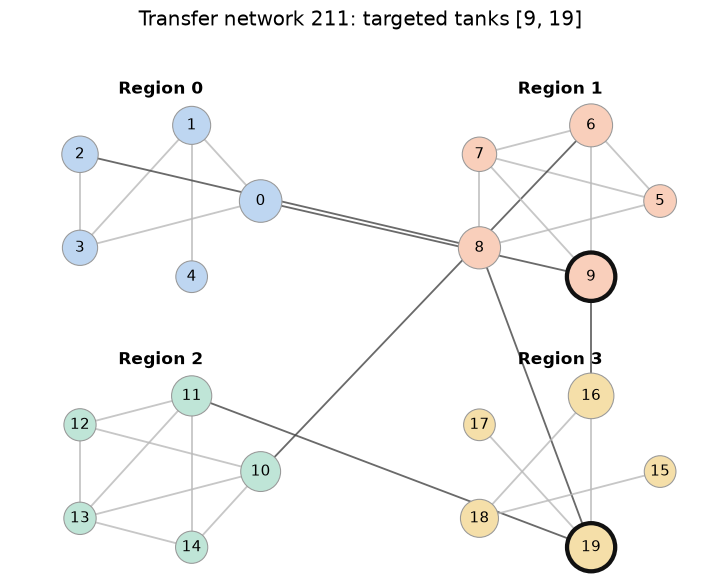

In [5]:
targeted = next(record for record in records if record.config["strategy"] == "betweenness")
cfg = next(cfg for cfg in example_configs if cfg.strategy == "betweenness")
network = generate_network(network_seed=cfg.network_seed, p_in=cfg.p_in, p_out=cfg.p_out,
                           n_tanks=cfg.n_tanks, n_regions=cfg.n_regions,
                           max_attempts=cfg.network_max_attempts)
assert network.network_hash == targeted.network["network_hash"]
graph = network.graph()
centres = [(-2, 1.7), (2, 1.7), (-2, -1.7), (2, -1.7)]
region_colors = ["#bed6f1", "#f9cfbb", "#bfe5d7", "#f5dfa9"]
positions = {}
for tank in graph:
    angle = 2 * np.pi * (tank % cfg.tanks_per_region) / cfg.tanks_per_region
    centre = centres[network.regions[tank]]
    positions[tank] = (centre[0] + np.cos(angle), centre[1] + np.sin(angle))

fig, ax = plt.subplots(figsize=(8.2, 6.2))
nx.draw_networkx_edges(
    graph, positions, ax=ax,
    edge_color=["#454545" if network.regions[u] != network.regions[v] else "#b9b9b9"
                for u, v in graph.edges], width=1.2, alpha=0.8,
)
nx.draw_networkx_nodes(
    graph, positions, ax=ax,
    node_color=[region_colors[network.regions[t]] for t in graph],
    node_size=[430 + 1800 * network.betweenness[t] for t in graph],
    edgecolors=["#111111" if t in targeted.selected_tanks else "#999999" for t in graph],
    linewidths=[2.8 if t in targeted.selected_tanks else 0.7 for t in graph],
)
nx.draw_networkx_labels(graph, positions, ax=ax, font_size=10)
for region, centre in enumerate(centres):
    ax.text(centre[0], centre[1] + 1.35, f"Region {region}", ha="center", weight="bold")
ax.set_title(f"Transfer network {example_network}: targeted tanks {targeted.selected_tanks}", pad=16)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3, 3.6)
ax.set_axis_off()
plt.show()
plt.close(fig)

### What changes each day?

The following table comes from the newly executed targeted run, not from a hand-written trace. Day 0 is the initial snapshot. Each later row records the result of one daily update.

The table shows the first few days and the quarantine boundaries. It separates quarantine-rule blocks from capacity blocks. The origin-quarantine rule is checked first, so its counter includes some attempts that might also have failed because neighbouring tanks were full. These are rule-attribution counts, not a count of additional successful transfers prevented.

In [6]:
daily = pd.DataFrame([
    {key: value for key, value in asdict(day).items() if key != "tanks"}
    for day in targeted.daily
]).set_index("day")
daily["Selected tank states"] = [
    ", ".join(f"{tank['tank_id']}: {tank['management_state']}"
              for tank in day.tanks if tank["tank_id"] in targeted.selected_tanks)
    for day in targeted.daily
]

start_day = targeted.intervention_start_day
boundary_days = set()
if start_day is not None:
    end_day = start_day + cfg.quarantine_duration
    boundary_days = {start_day - 1, start_day, end_day - 1, end_day}
show_days = sorted((set(range(6)) | boundary_days) & set(daily.index))
display(daily.loc[show_days, [
    "S", "I", "R", "new_infections", "recoveries",
    "accepted_transfers", "blocked_quarantine_out", "blocked_quarantine_in",
    "blocked_capacity", "Selected tank states",
]])

assert daily[["S", "I", "R"]].sum(axis=1).eq(cfg.n_agents).all()
assert daily["attempted_transfers"].eq(daily["accepted_transfers"] + daily["blocked_transfers"]).all()
assert daily["blocked_transfers"].eq(daily[[
    "blocked_quarantine_out", "blocked_quarantine_in", "blocked_capacity"
]].sum(axis=1)).all()
assert np.array_equal(daily["I"].diff().iloc[1:], (daily["new_infections"] - daily["recoveries"]).iloc[1:])
assert np.array_equal(daily["R"].diff().iloc[1:], daily["recoveries"].iloc[1:])
print("Daily population, disease transitions and transfer counts reconcile.")

,S,I,R,new_infections,recoveries,accepted_transfers,blocked_quarantine_out,blocked_quarantine_in,blocked_capacity,Selected tank states
day,,,,,,,,,,
0,199,1,0,0,0,0,0,0,0,"9: open, 19: open"
1,198,2,0,1,0,3,0,0,0,"9: open, 19: open"
2,195,5,0,3,0,2,0,0,0,"9: open, 19: open"
3,189,9,2,6,2,1,0,0,0,"9: open, 19: open"
4,188,9,3,1,1,8,0,0,0,"9: open, 19: open"
5,188,9,3,0,0,10,0,0,0,"9: open, 19: open"
32,155,12,33,0,0,3,0,0,0,"9: open, 19: open"
33,152,14,34,3,1,6,0,0,0,"9: quarantined, 19: quarantined"
46,128,16,56,0,0,8,0,0,0,"9: quarantined, 19: quarantined"


Daily population, disease transitions and transfer counts reconcile.


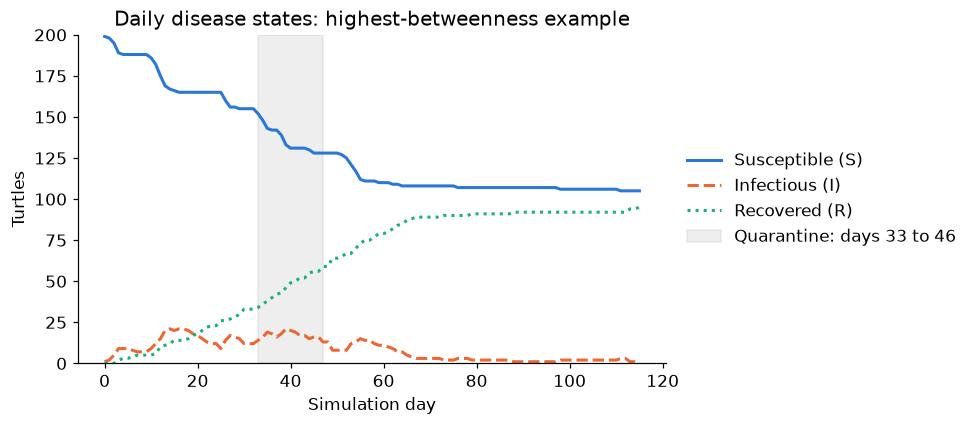

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
state_labels = {"S": "Susceptible (S)", "I": "Infectious (I)", "R": "Recovered (R)"}
state_colors = {"S": "#2a78d6", "I": "#eb6834", "R": "#1baf7a"}
for state, style in zip(("S", "I", "R"), ("-", "--", ":")):
    ax.plot(daily.index, daily[state], color=state_colors[state], linestyle=style,
            linewidth=2, label=state_labels[state])
if start_day is not None:
    ax.axvspan(start_day, end_day, color="#888888", alpha=0.14,
               label=f"Quarantine: days {start_day} to {end_day - 1}")
ax.set(xlabel="Simulation day", ylabel="Turtles", ylim=(0, cfg.n_agents),
       title="Daily disease states: highest-betweenness example")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
plt.show()
plt.close(fig)

In [8]:
random_rates = [record.metrics["final_attack_rate"] for record in records
                if record.config["strategy"] == "random"]
example_difference = targeted.metrics["final_attack_rate"] - np.mean(random_rates)
display(Markdown(
    f"In this block, the targeted attack rate minus the mean of the three random-policy attack rates "
    f"is **{100 * example_difference:+.1f} percentage points**. "
    "A negative difference favours targeting; a positive difference favours random selection. "
    "This one block cannot establish which strategy works better across networks and outbreaks."
))

In this block, the targeted attack rate minus the mean of the three random-policy attack rates is **-25.7 percentage points**. A negative difference favours targeting; a positive difference favours random selection. This one block cannot establish which strategy works better across networks and outbreaks.

### Watching the same block

The animation below shows this block day by day, with the three strategies side by side: no quarantine, the two highest-betweenness tanks, and the random policy seed whose attack rate is the median of the three. All three panels use the same network, the same first case and the same event-keyed draws, so they are identical until quarantine starts on day 33. After that, the only difference is which two tanks are closed. Like the table above, one block shows the mechanism; it is not evidence for or against targeting.

![Animated example block: no quarantine, targeted and random quarantine side by side](../data/results/demo/example-block.gif)

The recorded GIF uses the same configuration as this section. A silent three-minute backup video of the original experiment is in [`data/results/demo/demo-3min.mp4`](../data/results/demo/demo-3min.mp4); the follow-up results are presented later in this notebook.

## 6. Recalculate the formal comparisons

Final attack rate is the fraction of all 200 turtles ever infected, including the initial case. Affected tanks counts tanks that contained an infectious turtle at any point, including during movement. It is not just the number infected at the last snapshot.

The analysis below uses all formal blocks, including outbreaks that ended before quarantine started. For each paired comparison, it first averages the three random-policy outcomes, then subtracts that average from the targeted outcome. The three policy seeds are not treated as three independent epidemic blocks.

Confidence intervals use 2,000 bootstrap resamples of whole networks, with bootstrap seed 0, as in the report. The notebook recomputes both primary outcomes and checks the results against the committed analysis tables. It does not rerun the 5,200 simulations.

In [9]:
conditions = condition_summary(summary, metrics=PRIMARY, n_boot=2000, seed=0)
differences = paired_differences(summary, metrics=PRIMARY,
                                 expected_policy_seeds=len(design.policy_seeds))
assert differences.attrs["dropped_blocks"] == 0
assert differences.attrs["incomplete_blocks"] == 0
effects = paired_effect_table(differences, metrics=PRIMARY, n_boot=2000, seed=0)

def check_table(actual, expected, keys):
    """Compare recalculated values with the committed table, allowing CSV rounding."""
    left = actual.sort_values(keys).reset_index(drop=True)
    right = expected[expected["metric"].isin(PRIMARY)][left.columns].sort_values(keys).reset_index(drop=True)
    # The shared baseline has no delay; CSV and pandas represent that missing value differently.
    for table in (left, right):
        table["response_delay"] = pd.array(table["response_delay"], dtype="Float64")
    pd.testing.assert_frame_equal(left, right, check_dtype=False, check_exact=False,
                                  rtol=1e-10, atol=1e-12)

check_table(conditions, pd.read_csv(analysis_dir / "condition-summary.csv"),
            ["transfer_rate", "response_delay", "strategy", "metric"])
check_table(effects, pd.read_csv(analysis_dir / "paired-effects.csv"),
            ["subset", "transfer_rate", "response_delay", "quarantine_duration", "metric"])

display(pd.DataFrame({
    "Check": ["Primary-outcome condition summaries", "Paired effect estimates and intervals",
              "Incomplete or failed paired blocks"],
    "Result": ["Match committed table", "Match committed table", "0"],
}))

,Check,Result
0,Primary-outcome condition summaries,Match committed table
1,Paired effect estimates and intervals,Match committed table
2,Incomplete or failed paired blocks,0


### Transfer rate, delay and outbreak size

Each point is a condition mean; bars show network-cluster 95% confidence intervals. The same no-quarantine baseline appears in each delay panel for comparison, not as new observations.

Transfer levels are equally spaced on the horizontal axis to show the four tested settings clearly. No values between them were simulated. Each random-strategy point contains 300 runs within 100 blocks; the other strategies have 100 runs per condition.

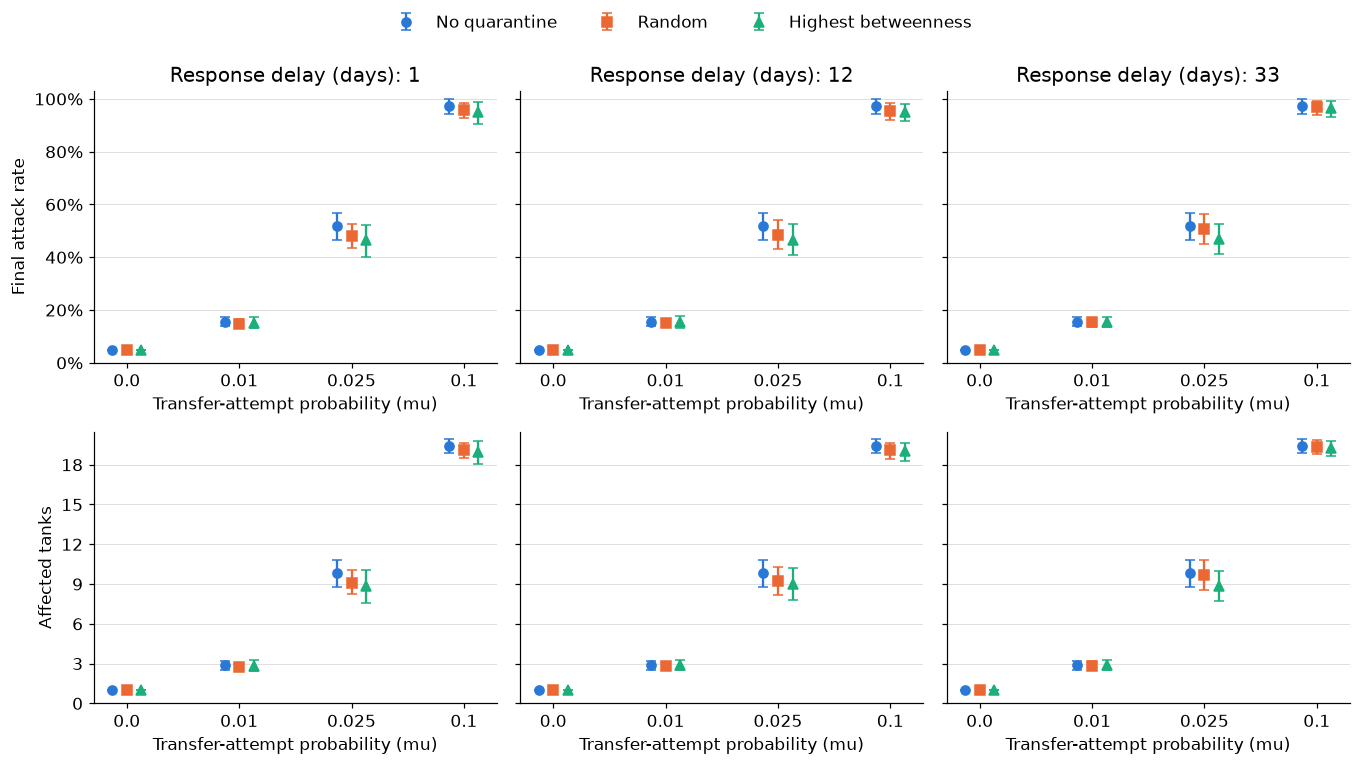

In [10]:
fig, axes = plt.subplots(2, len(design.response_delays), figsize=(12.5, 7), sharey="row")
levels = list(design.transfer_rates)
x = np.arange(len(levels))
for row, metric in enumerate(PRIMARY):
    for col, delay in enumerate(design.response_delays):
        ax = axes[row, col]
        for offset, strategy in zip((-0.13, 0, 0.13), STRATEGIES):
            values = conditions[(conditions["metric"] == metric) & (conditions["strategy"] == strategy)]
            if strategy != "none":
                values = values[values["response_delay"] == delay]
            values = values.set_index("transfer_rate").loc[levels]
            error = np.maximum(0, np.array([
                values["mean"] - values["ci95_low"],
                values["ci95_high"] - values["mean"],
            ]))
            ax.errorbar(x + offset, values["mean"], yerr=error, linestyle="none",
                        marker=MARKERS[strategy], color=COLORS[strategy], capsize=3,
                        label=LABELS[strategy])
        ax.set_xticks(x, [str(level) for level in levels])
        ax.set_xlabel("Transfer-attempt probability (mu)")
        ax.grid(axis="y", color="#dddddd", linewidth=0.6)
        if row == 0:
            ax.set_title(f"Response delay (days): {delay}")
            ax.set_ylim(0, 1.03)
            ax.yaxis.set_major_formatter(PercentFormatter(1))
        else:
            ax.set_ylim(0, cfg.n_tanks + 0.5)
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0, 0].set_ylabel("Final attack rate")
axes[1, 0].set_ylabel("Affected tanks")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()
plt.close(fig)

In [11]:
baseline = conditions[conditions["strategy"] == "none"].set_index(["metric", "transfer_rate"])
attack_ratio = baseline.loc[("final_attack_rate", 0.025), "mean"] / baseline.loc[("final_attack_rate", 0.01), "mean"]
tank_ratio = baseline.loc[("affected_tanks", 0.025), "mean"] / baseline.loc[("affected_tanks", 0.01), "mean"]
display(Markdown(
    f"Without quarantine, increasing the transfer rate from 0.01 to 0.025 multiplies the mean attack rate "
    f"by **{attack_ratio:.1f}** and the mean number of affected tanks by **{tank_ratio:.1f}**. "
    "At zero movement, the outbreak remains in its initial tank. At the highest transfer rate, "
    "outcomes approach saturation. These comparisons describe the tested model, not a calibrated farm."
))

Without quarantine, increasing the transfer rate from 0.01 to 0.025 multiplies the mean attack rate by **3.3** and the mean number of affected tanks by **3.4**. At zero movement, the outbreak remains in its initial tank. At the highest transfer rate, outcomes approach saturation. These comparisons describe the tested model, not a calibrated farm.

### Does targeting beat random quarantine?

The next plot shows targeted minus random, using all blocks at the three non-zero transfer rates. For attack rate, differences are in **percentage points**, not relative percent reductions. For affected tanks, differences are in **tanks**.

Negative values favour targeting. An interval spanning zero does not establish a direction of advantage. These are individual 95% intervals, not simultaneous intervals adjusted for all comparisons.

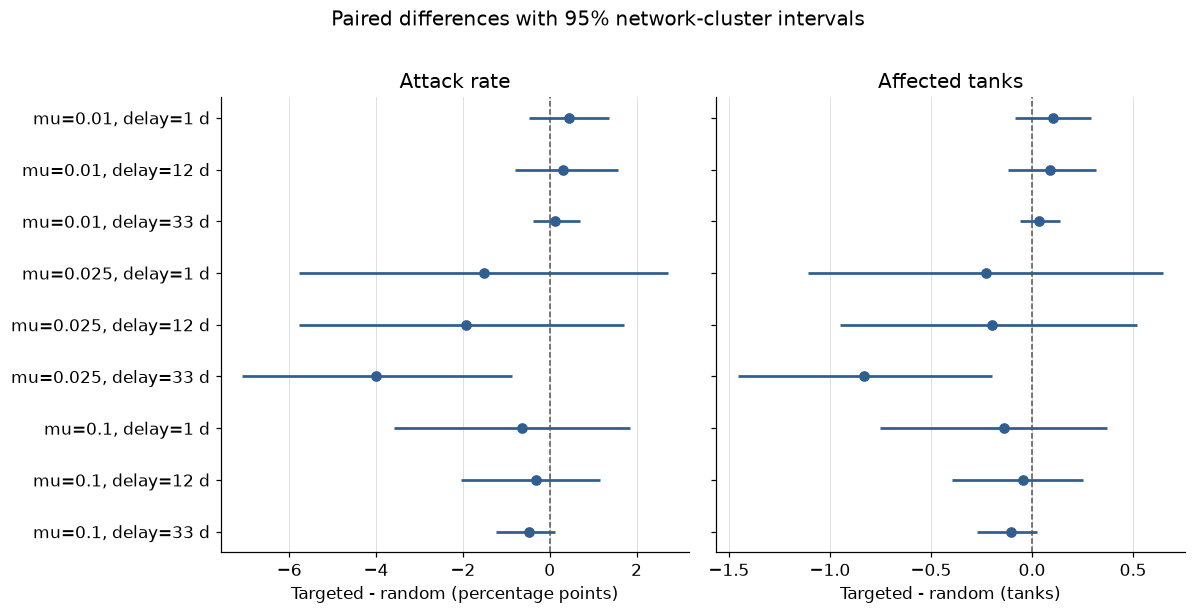

In [12]:
plotted_effects = effects[(effects["subset"] == "all_blocks") & (effects["transfer_rate"] > 0)].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
for ax, metric in zip(axes, PRIMARY):
    values = plotted_effects[plotted_effects["metric"] == metric].sort_values(["transfer_rate", "response_delay"])
    scale = 100 if metric == "final_attack_rate" else 1
    y = np.arange(len(values))
    for position, (_, value) in zip(y, values.iterrows()):
        ax.hlines(position, scale * value["mean_diff_ci95_low"], scale * value["mean_diff_ci95_high"],
                  color="#315e91", linewidth=1.8)
        ax.plot(scale * value["mean_diff"], position, "o", color="#315e91")
    ax.axvline(0, color="#555555", linestyle="--", linewidth=1)
    ax.set_yticks(y, [f"mu={r.transfer_rate:g}, delay={int(r.response_delay)} d"
                     for r in values.itertuples()])
    ax.set_title("Attack rate" if metric == "final_attack_rate" else "Affected tanks")
    ax.set_xlabel("Targeted - random (percentage points)" if metric == "final_attack_rate"
                  else "Targeted - random (tanks)")
    ax.grid(axis="x", color="#dddddd", linewidth=0.6)
axes[0].invert_yaxis()
fig.suptitle("Paired differences with 95% network-cluster intervals", y=1.01)
fig.tight_layout()
plt.show()
plt.close(fig)

In [13]:
outside_zero = (
    (plotted_effects["mean_diff_ci95_low"] > 0)
    | (plotted_effects["mean_diff_ci95_high"] < 0)
)
display(Markdown(
    f"Only **{int(outside_zero.sum())} of {len(plotted_effects)}** primary-outcome intervals exclude zero "
    "(nine transfer-rate/delay combinations and two outcomes). "
    "Under this budget and disease regime, the experiment does not show a consistent targeting advantage. "
    "Intervals spanning zero do not prove that the strategies are equivalent. "
    "The few intervals excluding zero also need caution because several comparisons were made."
))

Only **2 of 18** primary-outcome intervals exclude zero (nine transfer-rate/delay combinations and two outcomes). Under this budget and disease regime, the experiment does not show a consistent targeting advantage. Intervals spanning zero do not prove that the strategies are equivalent. The few intervals excluding zero also need caution because several comparisons were made.

## 7. Follow-up: what does the original result leave open?

The formal comparison uses one duration and only three random-policy draws. It does not directly estimate the difference between response delays. The separate [follow-up protocol](../data/methods/followup.md) addresses these limits without changing the movement or SIR rules.

We first compare delays using the existing formal runs. We then hold the transfer rate at 0.025 and test durations of 7, 14 and 28 days at delays 1, 12 and 33. Each network has 20 policy draws, shared across its five epidemics and every duration/delay condition. Duplicate pairs are retained. There are 19,000 follow-up runs; this notebook reads their compact summaries rather than rerunning the batch.

These are exploratory sensitivity checks on the same 20 networks and 100 epidemic blocks, not independent confirmation. Both strategies have equal budgets **within each duration**; increasing duration increases the budget from 14 to 28 to 56 tank-days. All paired contrasts include outbreaks ending before quarantine starts. Intervals resample whole networks 2,000 times with seed 20261009 and are pointwise, not adjusted for multiple comparisons.

Historical provenance retains the original source locations and analysis-code hashes. The checks below map the recorded result paths to their relocated files under `data/results/` and still verify the full source SHA-256 values.

In [14]:
from turtlefarm.followup import FollowupDesign
from turtlefarm.followup_analysis import analyse_followup, formal_delay_effects, verify_formal_replay

followup_design = FollowupDesign.from_json(ROOT / "data/config/followup-duration-policy.json")
followup_path = ROOT / "data/results/summary/followup-duration-policy.csv"
followup_dir = ROOT / "data/results/analysis/followup-duration-policy"
followup = pd.read_csv(followup_path)
assert len(followup) == 19000
assert followup["configuration_hash"].is_unique
assert set(followup["configuration_hash"]) == {
    configuration_hash(config.to_dict()) for config in followup_design.configs()
}
followup_tables = analyse_followup(
    followup, n_boot=2000, seed=20261009,
    expected_protocol_hash=followup_design.protocol_hash,
)
followup_tables["formal-delay-effects"] = formal_delay_effects(summary, n_boot=2000, seed=20261009)
for name, table in followup_tables.items():
    saved = pd.read_csv(followup_dir / f"{name}.csv")
    pd.testing.assert_frame_equal(table, saved, check_dtype=False, check_exact=False,
                                  rtol=1e-10, atol=1e-12)
followup_provenance = json.loads((followup_dir / "analysis-summary.json").read_text())
for name, path in (("formal", summary_path), ("followup", followup_path)):
    receipt = followup_provenance["sources"][name]
    recorded_path = Path(receipt["path"])
    # Original receipts are immutable; only the known results/ relocation is resolved here.
    if recorded_path.parts[:1] == ("results",):
        recorded_path = Path("data") / recorded_path
    assert not recorded_path.is_absolute(), "Expected a repository-relative source receipt."
    assert (ROOT / recorded_path).resolve() == path.resolve(), "Unexpected provenance source path."
    assert hashlib.sha256(path.read_bytes()).hexdigest() == receipt["sha256"]
replay = verify_formal_replay(summary, followup)
assert replay["matched_runs"] == 400
display(followup.groupby(["strategy", "status"]).size().rename("Runs").to_frame())
print("All seven follow-up tables match their recalculation.")
print("All 400 repeated formal baseline/targeted runs match the recorded historical outcomes.")

,,Runs
strategy,status,
betweenness,completed,900
none,completed,100
random,completed,18000


All seven follow-up tables match their recalculation.
All 400 repeated formal baseline/targeted runs match the recorded historical outcomes.


In [15]:
formal_delays = followup_tables["formal-delay-effects"]
delay_attack = formal_delays[
    formal_delays["transfer_rate"].eq(0.025) & formal_delays["metric"].eq("final_attack_rate")
].copy()
delay_attack[["mean_diff", "ci95_low", "ci95_high"]] *= 100
display(delay_attack[["strategy", "contrast", "mean_diff", "ci95_low", "ci95_high"]].rename(columns={
    "contrast": "Later delay - earlier delay (days)",
    "mean_diff": "Difference (pp)", "ci95_low": "95% lower (pp)", "ci95_high": "95% upper (pp)",
}).round(2))
display(Markdown(
    "These comparisons use the original 14-day formal design, including its three random-policy draws. "
    "At mu = 0.025, none of these attack-rate delay intervals excludes zero. "
    "That is uncertainty about the differences, not proof that timing has no effect. "
    "The full table covers all three nonzero transfer rates and both primary outcomes."
))

,strategy,Later delay - earlier delay (days),Difference (pp),95% lower (pp),95% upper (pp)
4,betweenness,12-1,0.31,-6.39,6.18
6,random,12-1,0.74,-2.68,4.40
16,betweenness,33-1,0.47,-4.47,5.42
18,random,33-1,2.95,-0.37,6.55
28,betweenness,33-12,0.16,-4.44,5.06
30,random,33-12,2.22,-0.85,5.10


These comparisons use the original 14-day formal design, including its three random-policy draws. At mu = 0.025, none of these attack-rate delay intervals excludes zero. That is uncertainty about the differences, not proof that timing has no effect. The full table covers all three nonzero transfer rates and both primary outcomes.

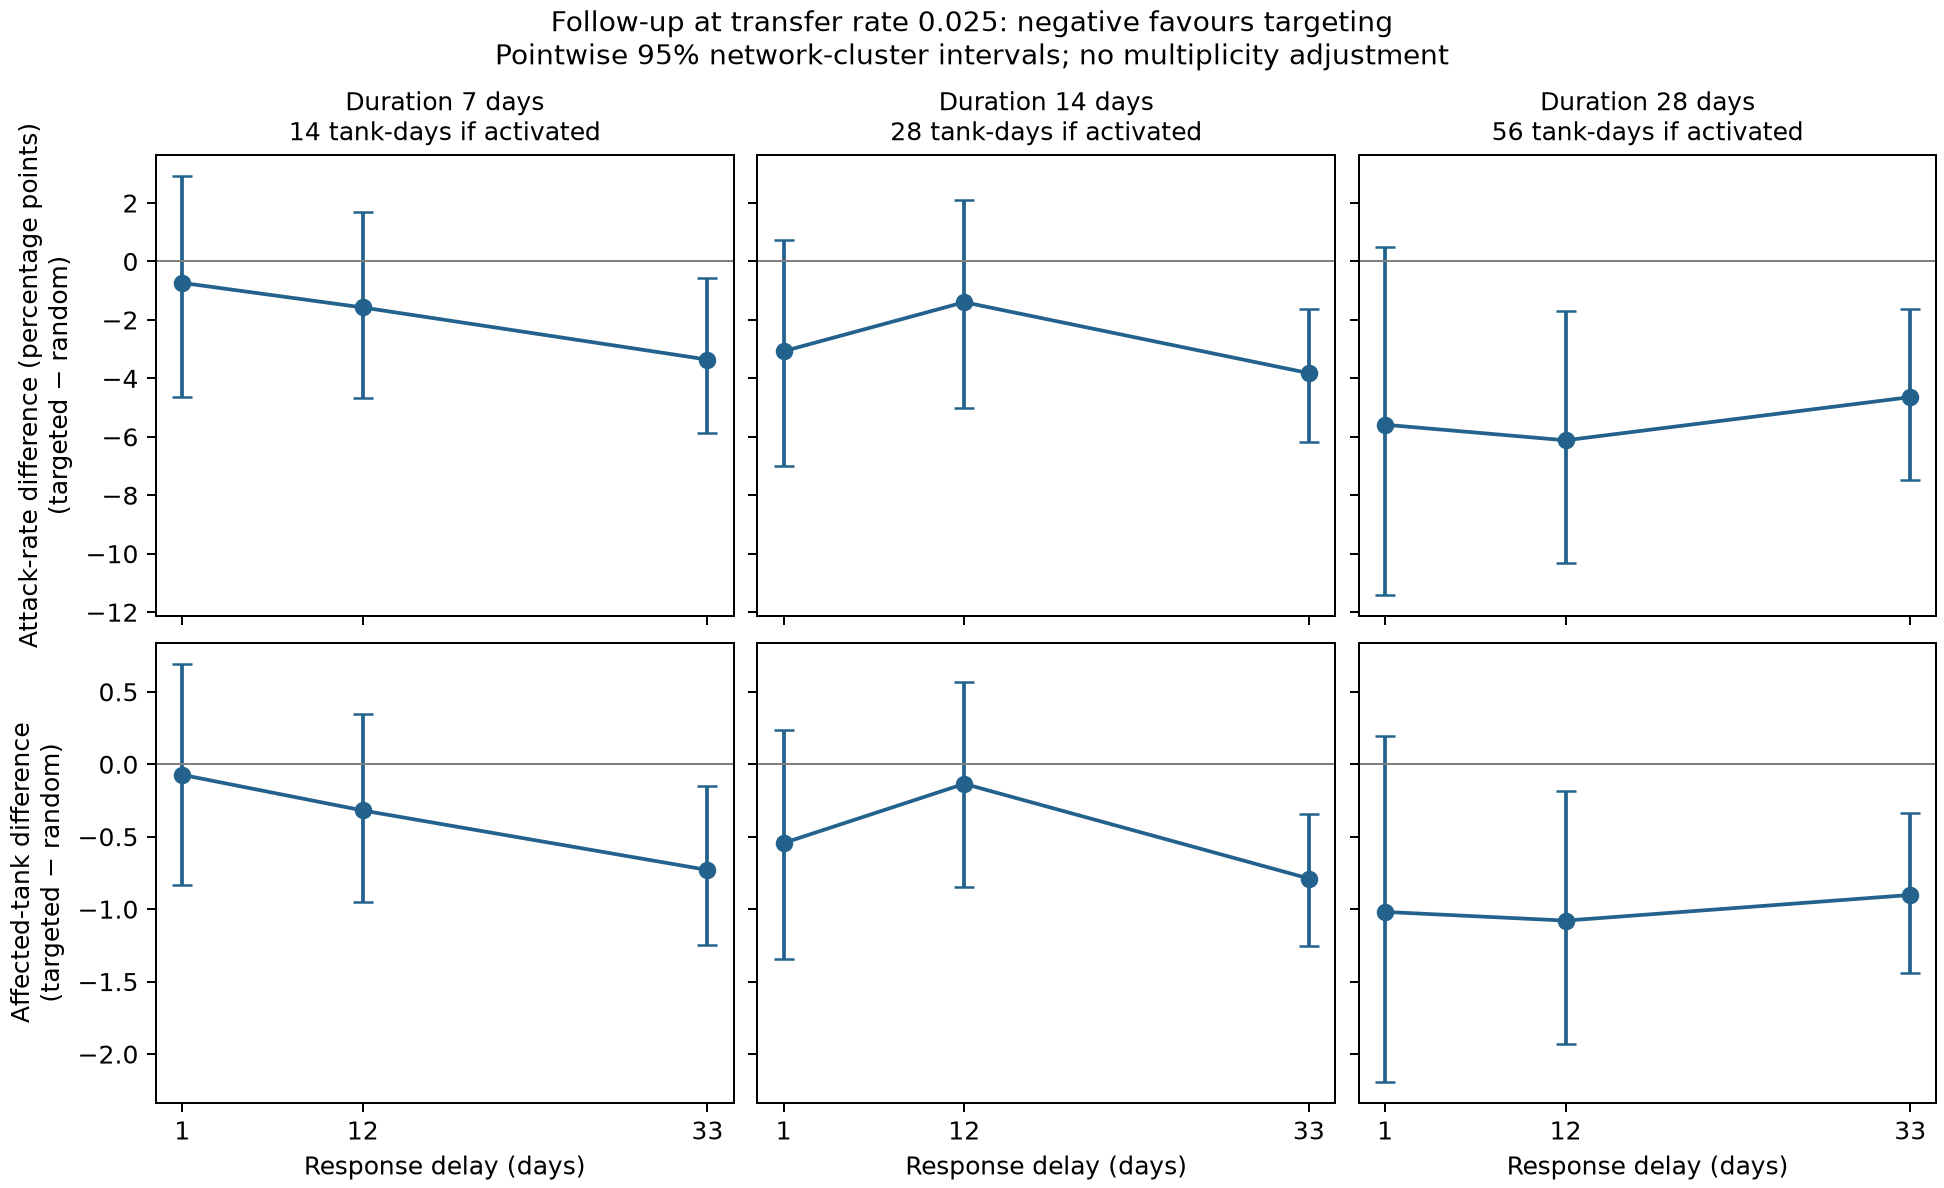

With 20 random-policy draws, the 14-day, delay-33 targeted-minus-random attack-rate difference is **-3.82 percentage points** (pointwise 95% interval -6.19 to -1.63). Some tested conditions favour targeting; others remain uncertain. The figure does not establish that targeting is universally better. Comparisons across duration columns also change the intervention budget.

In [16]:
from IPython.display import Image

# The committed figure displays the strategy-effect table checked in the preceding cells.
display(Image(filename=str(followup_dir / "fig-strategy-effects.png"),
              alt="Targeted minus random differences for attack rate and affected tanks across three durations and delays, with pointwise 95 percent network-cluster intervals. Negative values favour targeting."))
followup_primary = followup_tables["strategy-effects"]
followup_primary = followup_primary[followup_primary["metric"].isin(PRIMARY)]
d14_late = followup_primary[
    followup_primary["metric"].eq("final_attack_rate")
    & followup_primary["quarantine_duration"].eq(14)
    & followup_primary["response_delay"].eq(33)
].iloc[0]
display(Markdown(
    f"With 20 random-policy draws, the 14-day, delay-33 targeted-minus-random attack-rate difference is "
    f"**{100*d14_late['mean_diff']:+.2f} percentage points** "
    f"(pointwise 95% interval {100*d14_late['ci95_low']:+.2f} to {100*d14_late['ci95_high']:+.2f}). "
    "Some tested conditions favour targeting; others remain uncertain. "
    "The figure does not establish that targeting is universally better. "
    "Comparisons across duration columns also change the intervention budget."
))

In [17]:
coverage20 = followup_tables["policy-coverage"].query("policy_prefix == 20")
event_summary = followup_tables["condition-summary"]
baseline_events = event_summary[event_summary["strategy"].eq("none")].set_index("metric")
arrivals = baseline_events.loc["first_infectious_arrival"]
local_events = baseline_events.loc["first_local_secondary_infection"]
display(Markdown(
    f"The 400 network-specific policy draws contain **{int(coverage20['same_region_draws'].sum())} "
    f"same-region pairs**. Each network covers {int(coverage20['unique_pairs'].min())} to "
    f"{int(coverage20['unique_pairs'].max())} distinct tank pairs; duplicate draws were not replaced. "
    "The policy-stability table compares the first 5, 10 and 20 draws and reports Monte Carlo error "
    "conditional on these networks and epidemic seeds. This is not the network-bootstrap uncertainty.\n\n"
    f"In the 100 no-quarantine follow-up runs, **{int(arrivals['observed'])}** have an infectious arrival "
    f"outside the initial region and **{int(local_events['observed'])}** have a local S-to-I event there. "
    f"Among runs with each event, their mean first days are {arrivals['mean']:.2f} and "
    f"{local_events['mean']:.2f}, respectively. Non-events stay missing, not day zero. "
    "These event records distinguish arrival from local infection, including arrivals followed by "
    "same-day recovery. They do not identify the infector or prove why one policy performed better.\n\n"
    "The [follow-up results](../data/methods/followup.md) record the findings and remaining limits. "
    "The report has not yet been updated with this separate follow-up."
))

The 400 network-specific policy draws contain **115 same-region pairs**. Each network covers 17 to 20 distinct tank pairs; duplicate draws were not replaced. The policy-stability table compares the first 5, 10 and 20 draws and reports Monte Carlo error conditional on these networks and epidemic seeds. This is not the network-bootstrap uncertainty.

In the 100 no-quarantine follow-up runs, **79** have an infectious arrival outside the initial region and **79** have a local S-to-I event there. Among runs with each event, their mean first days are 21.72 and 21.89, respectively. Non-events stay missing, not day zero. These event records distinguish arrival from local infection, including arrivals followed by same-day recovery. They do not identify the infector or prove why one policy performed better.

The [follow-up results](../data/methods/followup.md) record the findings and remaining limits. The report has not yet been updated with this separate follow-up.

## 8. What the experiment establishes

Local infection, recovery and transfer rules produce a farm-level spread pattern without a rule telling an outbreak to cross regions. The formal experiment measures that pattern across networks and epidemic seeds. Transfer rate has a strong effect in the tested range, while selecting bridge tanks under the formal 14-day quarantine budget gives no consistent advantage across all tested conditions. The follow-up broadens random-policy coverage and finds condition-specific differences; it does not replace the original formal results.

The project also changed in response to checks: the first pilot grid failed its transfer-volume criterion, the formal experiment was rerun with nested epidemic seeds, and mixed transfer-blocking counts were replaced by separate rule-attribution counters for the pilot duration check. The [decision log](../data/methods/decisions.md) records when each decision was made and which changes followed inspection of results.

### Limits and further work

The formal experiment uses one disease regime, one tank capacity and one quarantine budget. Sensitivity analyses for beta, gamma and capacity have not been run. The model omits detection, births, deaths and disease-dependent movement.

Exploratory position and timing measures are computed by [utils/mechanism_analysis.py](../utils/mechanism_analysis.py). The separate follow-up now tests duration and delay at mu = 0.025 and records infectious arrivals separately from local infections. Neither analysis isolates every causal mechanism. Longer isolation also uses more tank-days, and the follow-up reuses the formal networks and epidemics. Other disease regimes and independent network samples remain further work.

The separately submitted report contains the full interpretation, references and protocol deviations. The [experiment methods](../data/methods/experiments.md) document the paired design.

## 9. Reproduction and code map

The notebook has checked both designs, rerun five example arms, reconciled daily counts and recalculated the formal and follow-up analysis tables. The 5,200 formal and 19,000 follow-up runs are read from their committed summaries, not regenerated here.

To regenerate the full experiment and its analysis separately, run these commands from the repository root. Raw result files are append-only; use `--resume` only when continuing an existing batch.

```bash
python -m pytest -c src/pytest.ini -q
python utils/run_experiment.py data/config/formal-nested.json
python utils/analyse_results.py formal-nested
python utils/mechanism_analysis.py
```

To reproduce the follow-up without replacing committed results, use a separate output directory. These commands do not build or modify the report:

```bash
python utils/run_followup.py data/config/followup-duration-policy.json --workers 4 --output-dir data/results/tmp/followup-reproduction
python utils/analyse_followup.py --followup data/results/tmp/followup-reproduction/summary/followup-duration-policy.csv --output data/results/tmp/followup-reproduction/analysis
```

| Component | Source |
|---|---|
| Daily updates, movement, quarantine and SIR | [src/turtlefarm/model.py](../src/turtlefarm/model.py) |
| Network generation and betweenness | [src/turtlefarm/network.py](../src/turtlefarm/network.py) |
| Paired random draws | [src/turtlefarm/rng.py](../src/turtlefarm/rng.py) |
| Design expansion and result records | [src/turtlefarm/runner.py](../src/turtlefarm/runner.py) |
| Paired differences and cluster bootstrap | [src/turtlefarm/analysis.py](../src/turtlefarm/analysis.py) |
| Exploratory position and timing measures | [utils/mechanism_analysis.py](../utils/mechanism_analysis.py) |
| Formal settings | [formal-nested.json](../data/config/formal-nested.json) |
| Observation-only event records | [src/turtlefarm/observation.py](../src/turtlefarm/observation.py) |
| Separate follow-up runner | [src/turtlefarm/followup.py](../src/turtlefarm/followup.py) |
| Follow-up comparisons and coverage | [src/turtlefarm/followup_analysis.py](../src/turtlefarm/followup_analysis.py) |
| Tests | [src/tests/](../src/tests/) |

Saved outputs belong to the settings shown in this notebook. After changing a cell, restart the kernel and run all cells before interpreting the results.